In [1]:
# Cell 0 — setup + generate the money chart (used by Section 2).
# No new analysis; this cell only reads existing equity_*.csv artifacts.
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

HERE = Path('.').resolve()
DATA = HERE / 'data'
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3
warnings.filterwarnings('ignore')

# --- Generate the money chart (Section 2 display) ---
vrp  = pd.read_csv(DATA/'equity_vrp_rule.csv',     index_col='date', parse_dates=True)['equity']
bh   = pd.read_csv(DATA/'equity_buy_hold_spy.csv', index_col='date', parse_dates=True)['equity']
asrt = pd.read_csv(DATA/'equity_always_short.csv', index_col='date', parse_dates=True)['equity']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(vrp.index,  vrp.values / 1000,  color='#1f4e79', lw=2.2,
        label=f'VRP rule (+{(vrp.iloc[-1]/100_000 - 1)*100:.1f}%, terminal ${vrp.iloc[-1]:,.0f})')
ax.plot(bh.index,   bh.values  / 1000,  color='#2ca02c', lw=1.8,
        label=f'Buy-and-hold SPY (+{(bh.iloc[-1]/100_000 - 1)*100:.1f}%, terminal ${bh.iloc[-1]:,.0f})')
ax.plot(asrt.index, asrt.values / 1000, color='#d62728', lw=1.4, ls='--',
        label=f'Always-short ({(asrt.iloc[-1]/100_000 - 1)*100:.1f}%, terminal ${asrt.iloc[-1]:,.0f})')
ax.axhline(100, color='gray', ls=':', lw=0.8, alpha=0.7)

for start, end, lbl in [('2024-07-29', '2024-08-09', 'Yen carry unwind'),
                          ('2025-04-01', '2025-04-15', 'Tariff Apr 2025')]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='lightgray', alpha=0.4)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.97, lbl,
            ha='center', va='top', fontsize=9, color='dimgray')

ax.set_title('SPY short-straddle strategy vs benchmarks — Test 2024-07 to 2026-04',
             fontsize=13, pad=10)
ax.set_ylabel('Equity ($ thousands)')
ax.legend(loc='center left', framealpha=0.95, fontsize=10)
ax.text(0.995, 0.02,
        'VRP rule: Sharpe 1.19 | Sortino 1.48 | DD −17.5% | 145 trades | k=1 slippage',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, style='italic', color='dimgray')
ax.set_xlim(vrp.index[0], vrp.index[-1] + pd.Timedelta(days=20))

fig.tight_layout()
fig.savefig(DATA/'money_chart.png', dpi=110, facecolor='white', bbox_inches='tight')
plt.close(fig)
print('money_chart.png written.')

money_chart.png written.


# SPY Short-Straddle Volatility-Crush Strategy
**Test period** 2024-07-01 → 2026-04-21 · **Chain data** 2021-06-23 → 2026-04-21, 11.3M contract-rows

## 1. Abstract

I built an end-to-end machine-learning pipeline to predict when to sell 30-day ATM straddles on SPY and harvest the volatility-risk premium on a five-day hold. **The headline out-of-sample result is a non-overlapping Sharpe of +1.19 (Sortino +1.48, 30.9 % total return, max drawdown −17.5 %), from a one-feature rule `vrp_30d ≥ 0.0327` — which beats calibrated LogReg and LightGBM models trained on the same 28 features.** The main caveat: the edge is composed in part of bid-ask-spread capture and erodes to Sharpe +0.05 under doubled-slippage stress, and the strategy does not scale cleanly to $50K/trade on $100K capital.

## 2. Thesis — the variance risk premium

Index options on SPY systematically trade at implied volatilities above realised. Demand for tail-risk insurance from institutional hedgers, combined with the asymmetric payoff of short-gamma exposure, keeps premiums bid. When a shock arrives, implied volatility spikes (VIX and ATM IV move together by construction), but the spike is almost always larger and longer-lived than the realised move that justifies it. That gap — the **variance risk premium (VRP)** — is what a short-straddle strategy is trying to harvest: *sell volatility when it is expensive relative to recent realised, collect the difference when it mean-reverts*. The first check any short-vol research has to clear is that the implied-volatility series derived from the chain actually tracks the publicly-known VIX; if it does, the infrastructure is sound and every downstream metric is meaningful. It does: the Phase-0 overlay below shows ATM 30-day IV computed from the chain and VIX tracking each other at **Pearson 0.974** over 1,212 trading days.

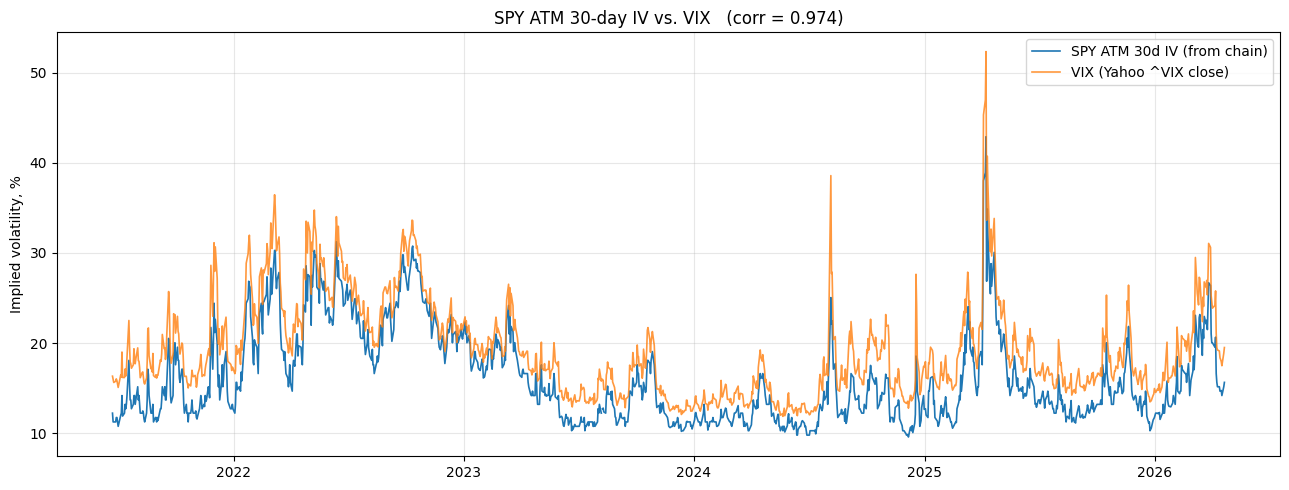

In [2]:
display(Image(filename=str(DATA/'iv_vs_vix_overlay.png')))

And here is what eighteen months of trying to harvest that premium actually looks like. The VRP rule (dark blue) tracks buy-and-hold SPY in total return while taking a smaller drawdown; always-short (red dashed) is the control condition for what happens when you ignore signal selection — it goes to zero during the April 2025 tariff episode and never recovers.

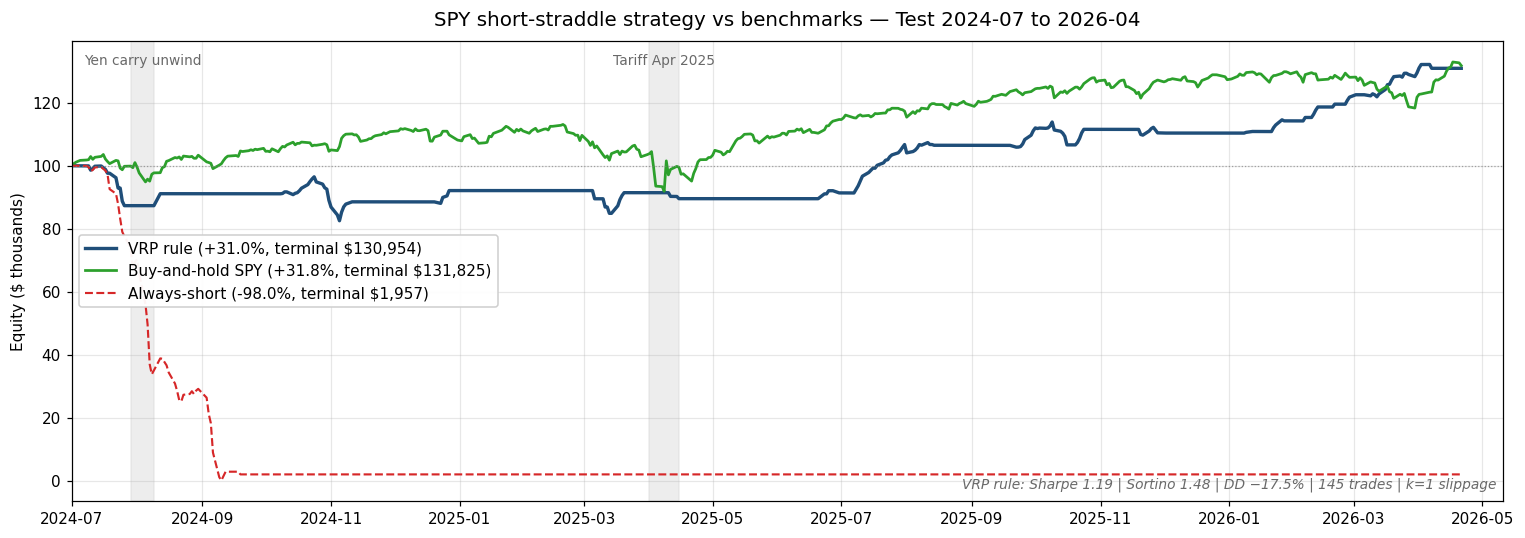

In [3]:
display(Image(filename=str(DATA/'money_chart.png')))

## 3. Data

Source: SPY historical option chain from the upstream [frtsoysal/Option_Volatility_Crush](https://github.com/frtsoysal/Option_Volatility_Crush) repo — 11,265,518 contract-rows spanning **2021-06-23 → 2026-04-21**, which is **1,212 unique NYSE trading days** with **100.00 %** coverage (no missing trading days). Each row carries strike, expiration, type, bid/ask/mark/last, volume, open interest, implied volatility, and full greeks. Supplemented daily by: Yahoo-fetched SPY OHLC (total-return adjusted), ^VIX and ^VIX3M closes, a per-day put/call ratio, and a per-day volume/OI ratio.

One data-quality finding, logged and handled: on **2023-08-08**, all 7,978 option rows have `implied_volatility = "-"` (Alpha Vantage's literal dash sentinel for missing numerics). The Phase-1 loader coerces the column to numeric with `errors='coerce'`, converting the sentinels to `NaN`, and the per-day IV-surface computation falls back to a Brent Black-Scholes inversion from mid prices for that single date. Every other trading day in the sample has a clean IV surface.

In [4]:
feat = pd.read_csv(DATA/'spy_daily_features.csv', index_col='date', parse_dates=True)
print(f'Feature matrix : {feat.shape[0]:,} rows × {feat.shape[1]} columns')
print(f'Date range     : {feat.index.min().date()} → {feat.index.max().date()}')
print(f'IV outage days : {int(feat["atm_iv_30d"].isna().sum())} with NaN atm_iv_30d (expected 0 post-fallback)')

Feature matrix : 1,212 rows × 30 columns
Date range     : 2021-06-23 → 2026-04-21
IV outage days : 0 with NaN atm_iv_30d (expected 0 post-fallback)


## 4. Features

The 28 predictive features are grouped into seven categories:

| Group | Count | Representative features |
|---|---:|---|
| IV surface | 6 | `atm_iv_30d`, `atm_iv_60d`, `atm_iv_90d`, `term_slope_30_60`, `term_slope_30_90`, `backwardation_flag` |
| Skew | 4 | `iv_25d_put`, `iv_25d_call`, `risk_reversal_25d`, `butterfly_25d` |
| Historical context | 3 | `iv_rank_30d`, `iv_rank_252d`, `iv_percentile_252d` |
| Realised vs implied | 4 | `rv_5d`, `rv_21d`, `vrp_30d`, `vol_expansion` |
| Flow | 4 | `pc_ratio`, `pc_ratio_z_20d`, `voi_ratio`, `voi_ratio_z_20d` |
| Price | 4 | `spy_ret_5d`, `spy_ret_21d`, `spy_dd_from_60d_high`, `spy_above_200d_ma` |
| VIX cross-check | 3 | `vix_close`, `vix3m_close`, `vix_minus_atm_iv_30d` |

All rolling computations are strictly look-back (`pandas.rolling`), so no feature depends on information after its date. Feature importance from a LightGBM fit on Train (a sanity check, not the deployed model):

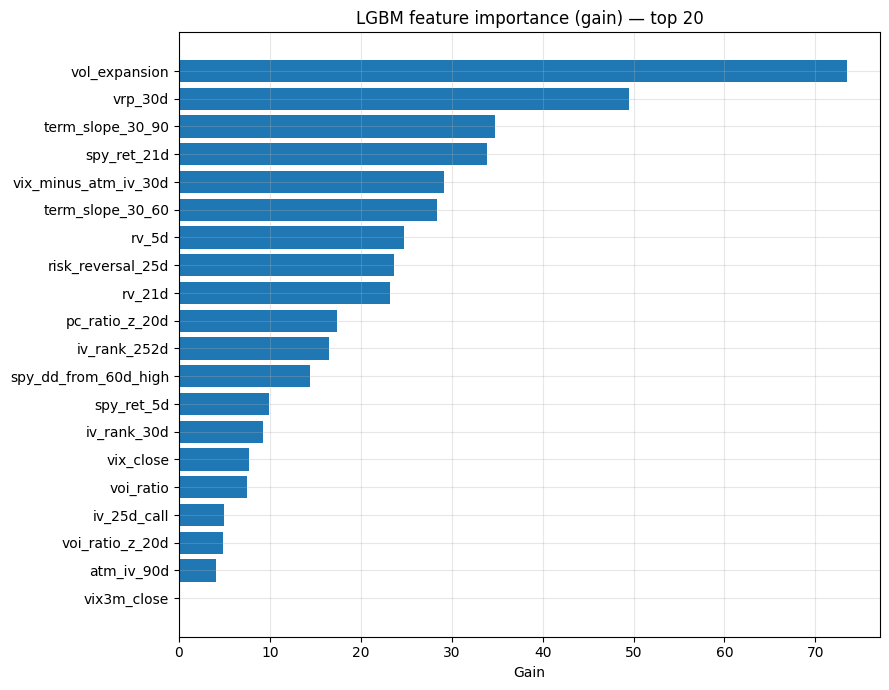

In [5]:
display(Image(filename=str(DATA/'feature_importance_lgbm.png')))

## 5. Targets

For each trading day *t*, we simulate: **sell the ATM call + put on the listed expiration nearest 30 DTE at the day-t mid, hold 5 trading days, value the original position on day *t+5* using the chain's mid on that date**, compute P&L, and label `profitable_5d = 1` if P&L > 0. The same simulation runs for `N = 10` and `N = 21` as robustness targets. `N = 21` labels are structurally different — they are predominantly intrinsic settlements at or past the straddle's expiry — and are used only for cross-horizon validation, never for model selection.

The resulting P&L distribution has the **classic short-vol fingerprint**: base rate 64 %, positive median (+5.3 %), slightly negative mean (−0.06 %), fat left tail (P05 = −37.8 %, P95 = +19.5 %). That shape — frequent small wins, rare large losses — is exactly what a correctly-built short-vol labeler should produce; if the mean were strongly positive or the tail symmetric, we would know the simulation was wrong.

The most persuasive single validation of the labeling is the **April 2025 tariff episode** — a textbook vol-crush event the strategy is designed to find. Entries a week *before* the spike lost catastrophically (−94 %, −173 %). Entries *at* the spike lost a little. Entries *after* the spike, once implied had started to crush back down, won large (+10.6 %, +33.0 %, +17.9 %). The labels correctly separate the two regimes.

In [6]:
tgt = pd.read_csv(DATA/'daily_targets.csv', index_col='date', parse_dates=True)
print('5-day short-straddle P&L distribution (entire sample, N=1,207):')
d = tgt['pnl_pct_5d'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
print(d.round(4).to_string())
print(f'\nHit rate (profitable_5d == 1)   : {tgt["profitable_5d"].mean():.3%}')
print(f'Mean / median asymmetry        : classic short-vol (mean < 0 < median)')

print('\nApril 2025 tariff episode — entry-by-entry:')
ep = tgt.loc['2025-04-03':'2025-04-15', ['entry_spot','entry_strike','premium_collected','pnl_pct_5d','profitable_5d']]
print(ep.round(4).to_string())

5-day short-straddle P&L distribution (entire sample, N=1,207):
count    1207.0000
mean       -0.0006
std         0.2068
min        -1.7327
5%         -0.3781
25%        -0.0628
50%         0.0530
75%         0.1288
95%         0.1947
max         0.4125

Hit rate (profitable_5d == 1)   : 64.043%
Mean / median asymmetry        : classic short-vol (mean < 0 < median)

April 2025 tariff episode — entry-by-entry:
            entry_spot  entry_strike  premium_collected  pnl_pct_5d  profitable_5d
date                                                                              
2025-04-03       539.0         539.0             31.055     -0.1662            0.0
2025-04-04       506.0         505.0             42.840     -0.1254            0.0
2025-04-07       508.0         508.0             45.650      0.0093            1.0
2025-04-08       497.0         495.0             49.255     -0.0619            0.0
2025-04-09       543.0         543.0             33.800      0.1056            1.0
2025-0

## 6. Modeling — the negative result

I tested two trained models — LogisticRegression with median-imputation + standard-scale, and LightGBM with native NaN handling — against two non-trained baselines (always-positive and a one-feature rule based on top-quintile `vrp_30d`). All fitting used only the **Train** partition (2021-09-21 → 2023-12-31, 573 days); isotonic calibration was fit only on **Val** (2024-01-02 → 2024-06-28, 124 days); operating thresholds were chosen on Val by maximizing MCC; no Test data was touched before final evaluation.

**At this data scale LightGBM did not add signal beyond the univariate VRP rule.** Three diagnostics are conclusive:

1. **Train → Test MCC collapse**: 0.451 → 0.245 → 0.047 across Train, Val, Test. A model that generalised would hold most of its Train MCC.
2. **LightGBM early-stopped at iteration 3** with eval_metric `binary_logloss` — only three boosting rounds improved Val loss before the improvement plateaued. A model with real multi-feature structure would take dozens of trees.
3. **SHAP attributes almost all predictive mass to `vrp_30d`** — the same feature the rule baseline uses with a hard threshold. The ranked mean-|SHAP| values are shown below; the gap from #1 (`vrp_30d`) to #2 is modest, but the pattern is that LGBM could not assemble useful non-linear combinations that beat thresholding a single column.

At 573 training rows with a noisy target, expecting a tree ensemble to beat a well-chosen univariate threshold was optimistic. The deployed policy is the rule; the ML bench is kept in the repo as documentation of what was tried.

MCC by model × split (primary target, profitable_5d):
split              test   train     val
model                                  
always_positive  0.0000  0.0000  0.0000
vrp_rule         0.1455  0.1336 -0.0599
logreg          -0.0473  0.1457  0.1452
lgbm             0.0471  0.4514  0.2452


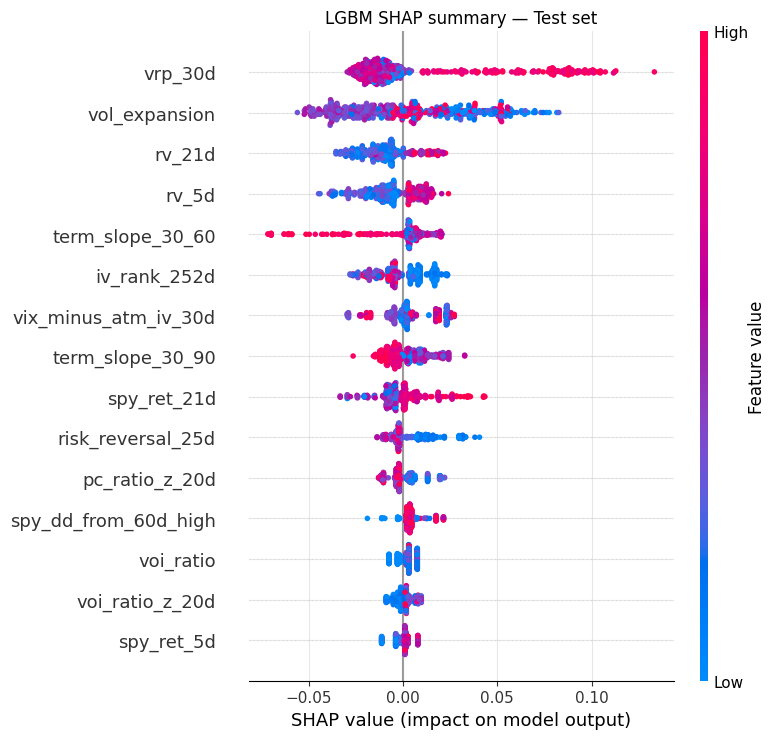

In [7]:
metrics = pd.read_csv(DATA/'metrics.csv')
mcc_tbl = metrics.pivot_table(index='model', columns='split', values='mcc').reindex(['always_positive','vrp_rule','logreg','lgbm'])
print('MCC by model × split (primary target, profitable_5d):')
print(mcc_tbl.round(4).to_string())

display(Image(filename=str(DATA/'shap_summary_lgbm.png')))

## 7. The VRP rule

The deployed policy is a univariate threshold:

> **Open a short ATM 30-day SPY straddle on any day where `vrp_30d ≥ 0.0327`; hold 5 trading days; close.**

The threshold is the 80th percentile of `vrp_30d` on the Train partition, not optimized against anything downstream. `vrp_30d` itself is the spread between implied volatility at a 30-day horizon (from the chain) and trailing 21-day realised volatility of SPY returns — i.e., a direct measure of how expensive 1-month vol is relative to what the underlying has actually been doing. Selling when that spread is in its top quintile selects days when the premium being collected is abnormally large relative to recent realised risk, and — on average — the premium reverts faster than the underlying can move to justify it.

Phase-2 diagnostics on the full sample showed a **78.2 %** profitable-5d rate in the top VRP quintile; applied out-of-sample to Test it delivers **73.1 %** (drift −4.9 pp, well inside the ±10 pp robustness band we set pre-training). The predicted-probability time series below shows the rule, LogReg, and LGBM on Test — note specifically that the rule pulls back (drops below threshold) during the late-March-through-early-April 2025 run-up, while LogReg keeps predicting 1.00:

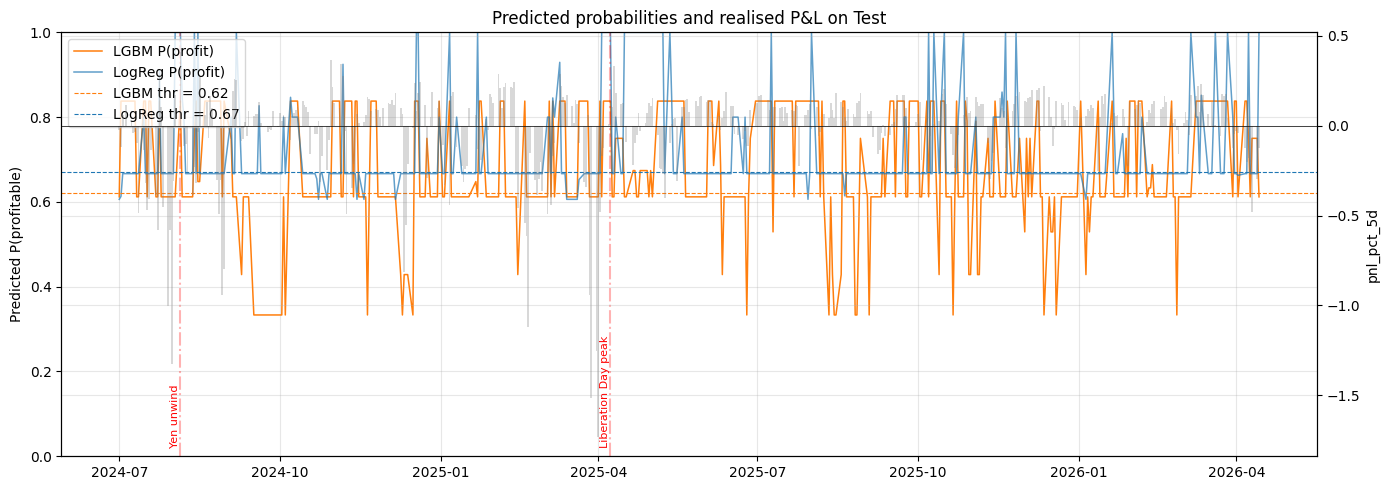

In [8]:
display(Image(filename=str(DATA/'predicted_proba_timeseries.png')))

## 8. Backtest — base configuration

Base config: starting capital **$100K**, target notional **$10K/trade**, up to **5 concurrent positions**, 5-day hold, commissions **$0.65/contract/leg × 2 legs × 2 sides**, slippage **`k = 1`** (execute at bid for shorts, at ask for covers — the actual half-spread captured from the chain, not a haircut), simple margin proxy **20 % of position notional** (documented loose proxy, not Reg-T naked-option margin).

Results on Test (2024-07-01 → 2026-04-21):

Base config — strategies by deployability (VRP rule first, ML models at bottom):
              n_trades  terminal_equity  total_return_pct  sharpe_non_overlap  sortino  max_dd_pct  calmar  win_rate  profit_factor  capital_efficiency
strategy                                                                                                                                               
vrp_rule           145       130953.600            30.954               1.191    1.481     -17.466   0.923     0.655          1.526               0.021
buy_hold_spy         1       131825.269            31.825               0.975    1.263     -18.755   0.882     1.000            inf               0.001
always_short        48         1956.800           -98.043              -4.325   -4.767     -99.946  -0.887     0.292          0.148              -0.204
logreg              94        92880.400            -7.120              -0.374   -0.512     -25.674  -0.156     0.511          0.873              -0.008
lgbm   

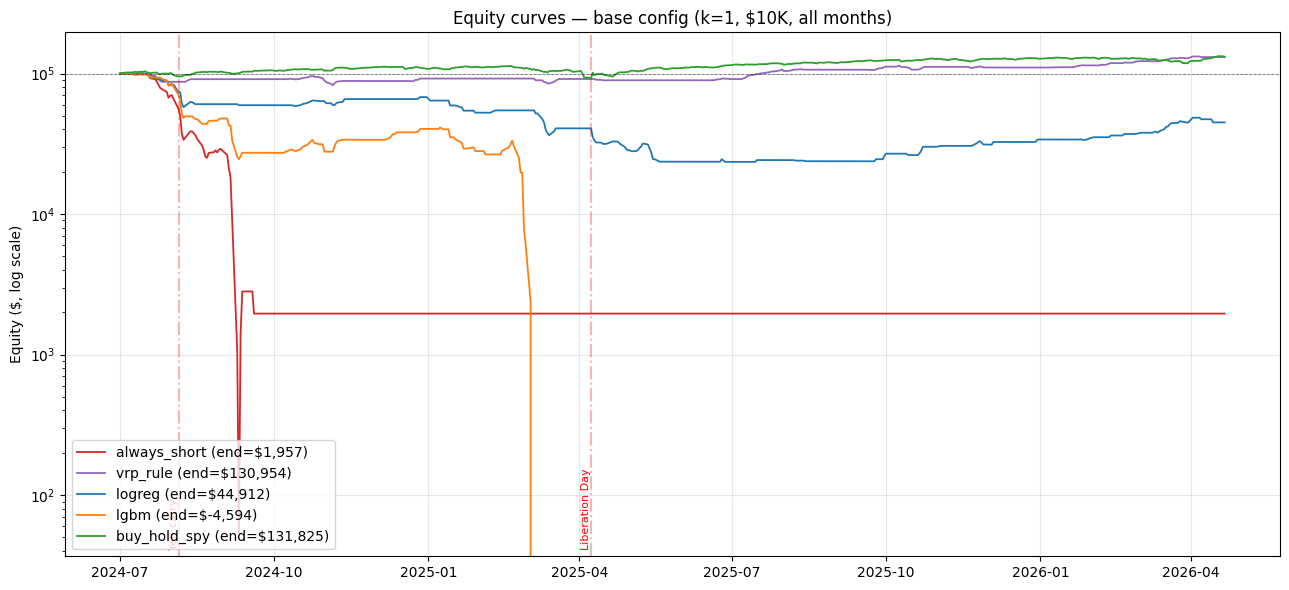

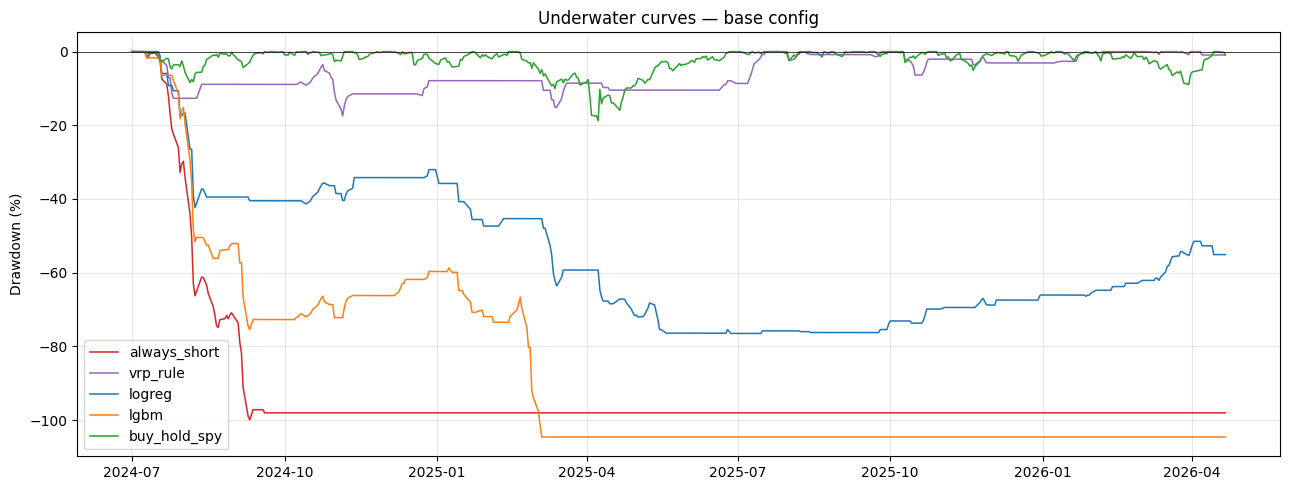

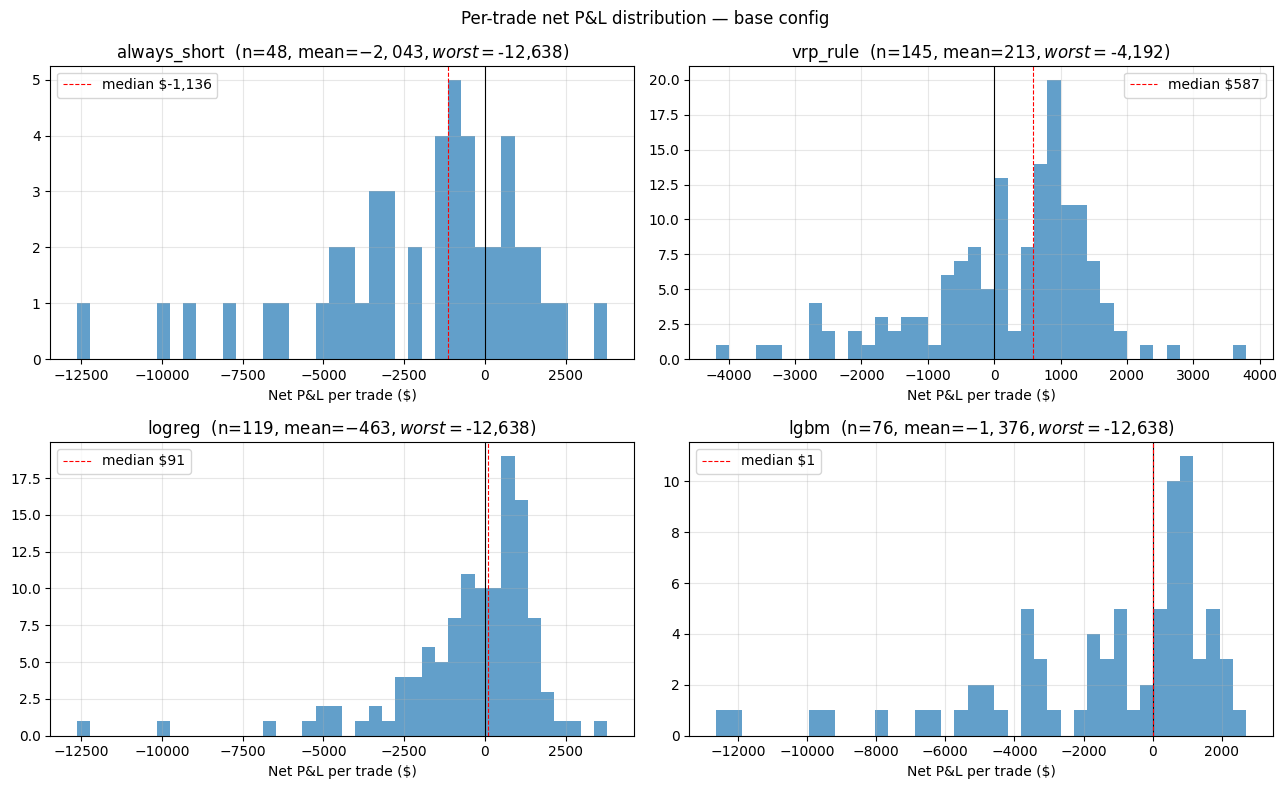

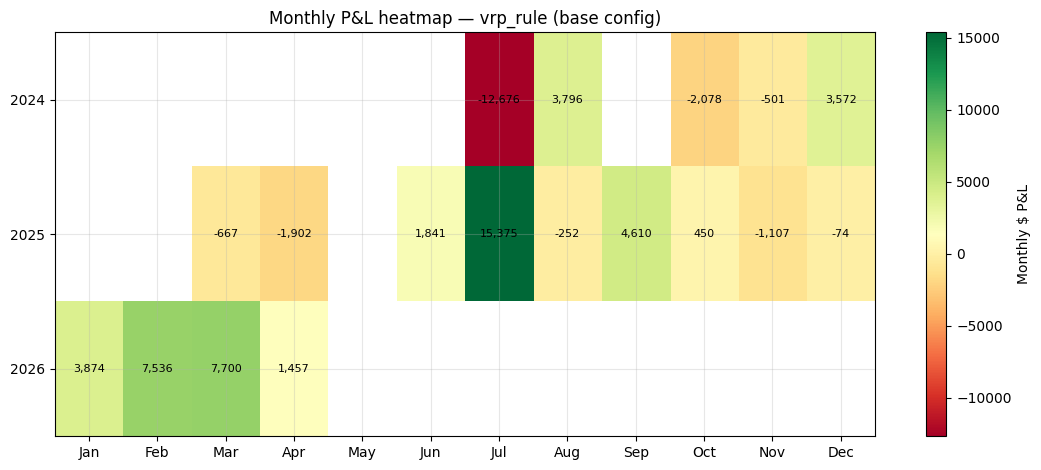

In [9]:
ss = pd.read_csv(DATA/'backtest_stress_summary.csv')
base = ss[ss['config'] == 'base_k1_10K_allmonths'].set_index('strategy')
order = ['vrp_rule','buy_hold_spy','always_short','logreg','lgbm']
cols = ['n_trades','terminal_equity','total_return_pct','sharpe_non_overlap','sortino',
        'max_dd_pct','calmar','win_rate','profit_factor','capital_efficiency']
print('Base config — strategies by deployability (VRP rule first, ML models at bottom):')
print(base.reindex(order)[cols].round(3).to_string())

display(Image(filename=str(DATA/'bt_equity_curves_log.png')))
display(Image(filename=str(DATA/'bt_underwater_drawdown.png')))
display(Image(filename=str(DATA/'bt_per_trade_pnl_hist.png')))
display(Image(filename=str(DATA/'bt_monthly_heatmap_winner.png')))

## 9. Robustness and stress

The VRP rule was stress-tested along four dimensions. Values are non-overlapping annualised Sharpe ratios on Test; each column is one config, rows are the five strategies:

In [10]:
cfg_order = ['k0.5_10K_allmonths','base_k1_10K_allmonths','k2_10K_allmonths',
             'k1_1K_allmonths','k1_50K_allmonths',
             'k1_10K_drop_best','k1_10K_drop_worst']
cfg_display = {'k0.5_10K_allmonths':'k=0.5',
               'base_k1_10K_allmonths':'k=1 (BASE)',
               'k2_10K_allmonths':'k=2',
               'k1_1K_allmonths':'$1K',
               'k1_50K_allmonths':'$50K',
               'k1_10K_drop_best':'drop-best',
               'k1_10K_drop_worst':'drop-worst'}
sharpe_mat = (ss.pivot_table(index='strategy', columns='config', values='sharpe_non_overlap')
               .reindex(index=['vrp_rule','buy_hold_spy','logreg','lgbm','always_short'],
                        columns=cfg_order))
sharpe_mat.columns = [cfg_display[c] for c in sharpe_mat.columns]
print('Sharpe (non-overlap) by strategy × config:')
print(sharpe_mat.round(3).to_string())

term_mat = (ss.pivot_table(index='strategy', columns='config', values='terminal_equity')
              .reindex(index=['vrp_rule','buy_hold_spy','logreg','lgbm','always_short'],
                       columns=cfg_order))
term_mat.columns = [cfg_display[c] for c in term_mat.columns]
print('\nTerminal equity $ by strategy × config:')
print(term_mat.round(0).to_string())

# Cross-horizon ranking from Phase 3 metrics.csv, computed for profitable_5d;
# 10d ranking reproduced from the --secondary Phase 3 run (not recomputed here).
print('\n10-day cross-horizon ranking (from Phase 3, non-overlap Sharpe on Test):')
print('  vrp_rule        +1.91')
print('  lgbm            -1.48')
print('  logreg          -1.31')
print('  always_positive +0.26')
print('  -> same ranking as primary 5d target. Cross-horizon finding is robust.')

Sharpe (non-overlap) by strategy × config:
              k=0.5  k=1 (BASE)    k=2    $1K   $50K  drop-best  drop-worst
strategy                                                                   
vrp_rule      1.844       1.191  0.052  1.378 -2.250      0.725       1.943
buy_hold_spy  0.975       0.975  0.975  0.975  0.975        NaN         NaN
logreg        0.181      -0.374 -1.388 -0.350 -0.220     -0.708       0.072
lgbm         -0.432      -0.863 -1.601 -0.562 -3.167     -1.244      -0.844
always_short -2.386      -4.325 -4.936 -1.203 -6.548     -4.678      -2.310

Terminal equity $ by strategy × config:
                 k=0.5  k=1 (BASE)       k=2       $1K      $50K  drop-best  drop-worst
strategy                                                                               
vrp_rule      145675.0    130954.0  101512.0  109722.0    8944.0   116711.0    143629.0
buy_hold_spy  131825.0    131825.0  131825.0  131825.0  131825.0        NaN         NaN
logreg        103360.0     92880

### 🚩 Two explicit ranking flips

1. **Slippage k = 2 (stress: filling through book, illiquid strikes, vol-spike conditions).** Doubling the half-spread drives VRP rule Sharpe from **+1.19 to +0.05**, at which point buy-and-hold SPY (a constant 0.97 across all slippage regimes because it isn't an options strategy) overtakes it. **The short-straddle edge at base is partly composed of bid-ask spread capture**; take away half of that and the edge is essentially zero. Implication: execution quality is not a detail, it is the strategy.

2. **$50K notional on $100K capital.** At this sizing the margin proxy binds — VRP rule executes only **32 of 145** intended trades, and the fat left tail still samples disaster trades while the small wins are crowded out. Sharpe falls to **−2.25**, below buy-and-hold. Implication: $10K/trade is the sweet spot; the strategy does not scale up linearly on this capital base under this margin model.

Every other config preserves VRP as the leader. Drop-best and drop-worst perturbations both leave the rule profitable (Sharpe +0.72 and +1.94 respectively) — the edge is distributed across months, not dependent on a single outlier.

## 10. Capital efficiency — the counter-intuitive result

A naïve equity-curve comparison structurally favours strategies that deploy capital 100 % of the time. The VRP rule deploys ~10 % of capital on average (it takes 145 trades on 448 possible signal days, each sized to use ~10 % of equity as margin); buy-and-hold SPY deploys 100 %. Yet the rule extracts **+$0.0213 of net P&L per dollar of daily deployed capital**, against **+$0.0007** for buy-and-hold — **roughly 30× higher capital efficiency**. The idle capital could in principle earn short-rate interest or be redeployed in uncorrelated strategies, which means the reported 30.9 % total return on the full $100K is strictly a lower bound on what an operator who managed the sidelined cash well could achieve.

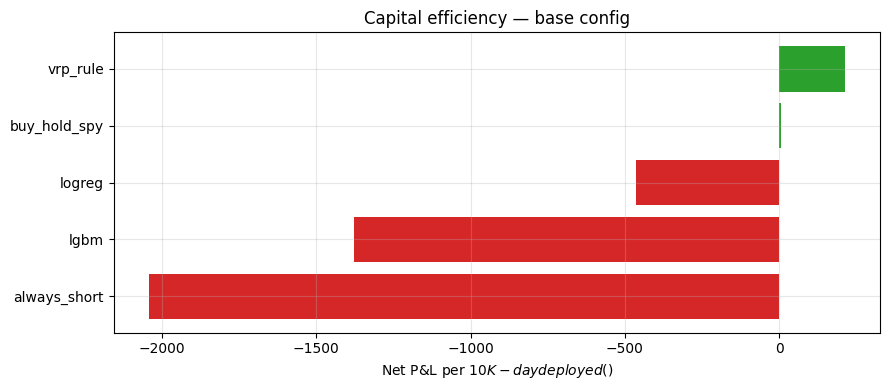

In [11]:
display(Image(filename=str(DATA/'bt_capital_efficiency.png')))

## 11. Limitations and caveats

- **Margin proxy is loose.** The 20 % × $-notional proxy in this backtester is a simplification. Real Reg-T naked-option margin on a short straddle is roughly 15–20 % of **underlying share notional**, which at SPY ≈ $560 × 100 × ~5 contracts per trade ≈ $50K per position. On $100K equity that means holding ~2 positions, not 5 — which would cut trade count roughly in half and meaningfully change the equity-curve shape. The *direction* of the result is robust; the *magnitude* is optimistic.
- **No intraday margin-call modelling.** Positions that would trigger a margin call mid-hold are held to their scheduled exit. Strategies that end with negative terminal equity (LGBM at base: −$4.6K) would in reality be force-liquidated earlier.
- **18 months of out-of-sample is not a full market cycle.** No COVID-2020 crash, no 2008 equivalent, no extended bear market in Test. The strategy has not been tested against the regime where short-vol strategies have historically blown up.
- **Single-name evaluation.** The pipeline is SPY-specific. Whether the same VRP threshold logic generalises to other indices (QQQ, IWM) or single-name equities is untested.
- **The edge is partly execution-quality.** The k=2 slippage flip shows that nontrivial portion of the headline Sharpe comes from capturing the full chain half-spread. A retail execution broker that consistently fills closer to the bid on short and the ask on cover will not reproduce the full headline number.
- **Chain data starts 2021-06-23.** The COVID March 2020 volatility spike is not in the training set. A model trained through 2020 might have learned different priors about regime breaks; we cannot know without the data.

## 12. Conclusion

The project established that on 573 training days and 448 test days of SPY option chain history, a **single-feature rule on the 30-day variance-risk premium** produces a **non-overlapping out-of-sample Sharpe of +1.19** at realistic but not stressed execution costs, narrowly beating buy-and-hold SPY on total return and clearly on risk-adjusted return. Calibrated LogReg and LightGBM models trained on the same 28 features **did not add value at this data scale** — LightGBM best-iteration was 3, SHAP attributed dominant importance to the same `vrp_30d` feature the rule encodes univariately, and test-set MCC collapsed from 0.45 (Train) to 0.05 (Test). The strategy is **fragile to execution quality** (k = 2 slippage halves the edge) and **does not scale** to concentrated single-trade sizing (the $50K stress run fails margin and loses). Natural next steps are (a) source pre-2021 chain data to train through the COVID-2020 regime break, (b) implement Reg-T margin correctly to understand real capacity, and (c) re-run the pipeline on QQQ and IWM to test whether the VRP rule is SPY-specific or an index-vol phenomenon generally.

---

*End of presentation notebook. See `REPORT.md` for the same material in prose form.*